## 4) Data

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [36]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [37]:
print(red.shape)
print(white.shape)
print(red.columns)
print(red.dtypes)

(1599, 12)
(4898, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [38]:
print(red.isnull().sum())
print(white.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [39]:
red['color'] = 'red'
white['color'] = 'white'
wine_data = pd.concat([red, white], ignore_index=True)
print(wine_data.shape)
print(wine_data.columns)
wine_data.head()

(6497, 13)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'color'],
      dtype='object')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [40]:
# rename the columns for consistency
wine_data = wine_data.rename(columns={
    "fixed acidity": "fixed_acidity",
    "volatile acidity": "volatile_acidity",
    "citric acid": "citric_acid",
    "residual sugar": "residual_sugar",
    "free sulfur dioxide": "free_sulfur_dioxide",
    "total sulfur dioxide": "total_sulfur_dioxide"
})

In [41]:
wine_data['color'] = wine_data['color'].map({'red': 0, 'white': 1})
wine_data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## 5) Prediction

In [42]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, accuracy_score, recall_score, precision_score, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, RidgeCV, LassoCV, LogisticRegressionCV


##### The training and test performances as the **linear** and **unregularized** model is being developed:

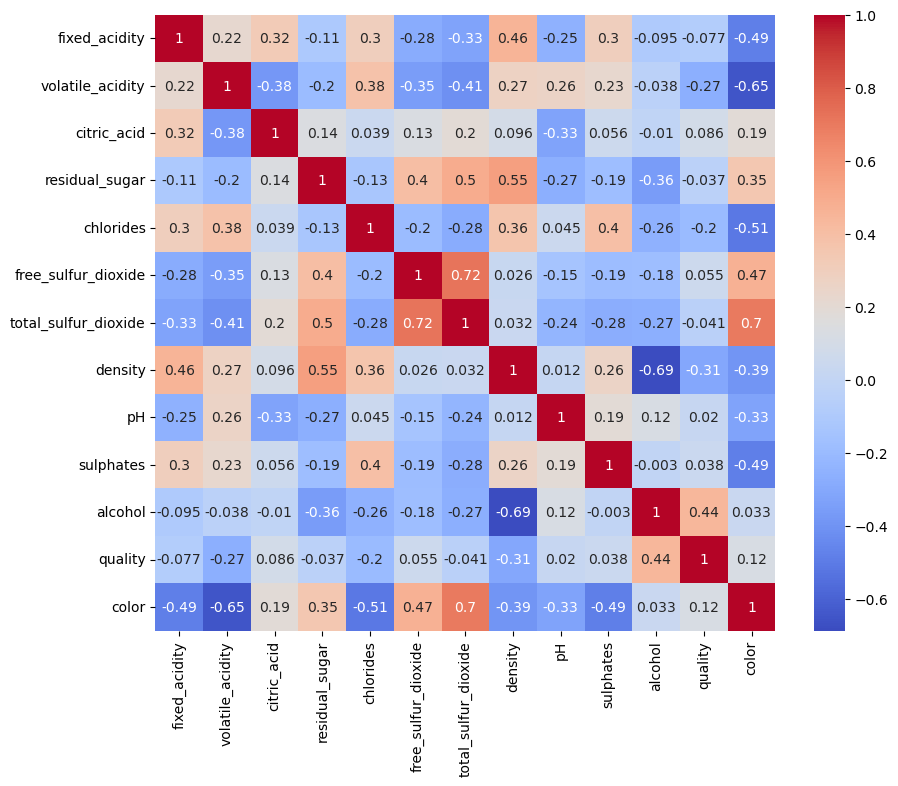

In [43]:
plt.figure(figsize=(10,8))
sns.heatmap(wine_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [44]:
# Split the data into training and testing sets
X = wine_data.drop(columns=['quality'])
y = wine_data['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

train = X_train.copy()
train['quality'] = y_train

test = X_test.copy()
test['quality'] = y_test

Training set size: 5197
Test set size: 1300


In [45]:
# start with 'alcohol' as the predictor beacause it has the highest correlation with quality.
model = smf.ols('quality ~ alcohol', data=train).fit()
print(model.summary())

train_preds = model.predict(train)
test_preds = model.predict(test)

train_rmse = np.sqrt(mean_squared_error(train['quality'], train_preds))
test_rmse = np.sqrt(mean_squared_error(test['quality'], test_preds))
train_mae = mean_absolute_error(train['quality'], train_preds)
test_mae = mean_absolute_error(test['quality'], test_preds)
train_r2 = r2_score(train['quality'], train_preds)
test_r2 = r2_score(test['quality'], test_preds)

results = pd.DataFrame({
    'Model': ['quality ~ alcohol'],
    'Training RMSE': [train_rmse],
    'Test RMSE': [test_rmse],
    'Training MAE': [train_mae],
    'Test MAE': [test_mae],
    'Training R^2': [train_r2],
    'Test R^2': [test_r2]
})
results

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     1297.
Date:                Sun, 16 Mar 2025   Prob (F-statistic):          8.77e-254
Time:                        17:45:44   Log-Likelihood:                -6122.6
No. Observations:                5197   AIC:                         1.225e+04
Df Residuals:                    5195   BIC:                         1.226e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3734      0.096     24.640      0.0

,Model,Training RMSE,Test RMSE,Training MAE,Test MAE,Training R^2,Test R^2
0,quality ~ alcohol,0.785976,0.76728,0.622745,0.60215,0.199806,0.187069


In [46]:
all_predictors = [col for col in train.columns if col != 'quality']
if 'alcohol' in all_predictors:
    all_predictors.remove('alcohol')
ordered_predictors = ['alcohol'] + all_predictors

for i in range(2, len(ordered_predictors) + 1):
    current_predictors = ordered_predictors[:i]
    formula = "quality ~ " + " + ".join(current_predictors)

    model = smf.ols(formula=formula, data=train).fit()
    
    train_preds = model.predict(train)
    test_preds = model.predict(test)
    
    train_rmse = np.sqrt(mean_squared_error(train['quality'], train_preds))
    test_rmse = np.sqrt(mean_squared_error(test['quality'], test_preds))
    train_mae = mean_absolute_error(train['quality'], train_preds)
    test_mae = mean_absolute_error(test['quality'], test_preds)
    train_r2 = r2_score(train['quality'], train_preds)
    test_r2 = r2_score(test['quality'], test_preds)
    
    new_row = pd.DataFrame([{
        'Model': formula,
        'Training RMSE': round(train_rmse, 2),
        'Test RMSE': round(test_rmse, 2),
        'Training MAE': round(train_mae, 2),
        'Test MAE': round(test_mae, 2),
        'Training R^2': round(train_r2, 2),
        'Test R^2': round(test_r2, 2)
    }])
    
    results = pd.concat([results, new_row], ignore_index=True)

results
        

,Model,Training RMSE,Test RMSE,Training MAE,Test MAE,Training R^2,Test R^2
0,quality ~ alcohol,0.785976,0.76728,0.622745,0.60215,0.199806,0.187069
1,quality ~ alcohol + fixed_acidity,0.790000,0.77000,0.620000,0.60000,0.200000,0.190000
2,quality ~ alcohol + fixed_acidity + volatile_a...,0.750000,0.74000,0.590000,0.57000,0.260000,0.240000
3,quality ~ alcohol + fixed_acidity + volatile_a...,0.750000,0.74000,0.590000,0.57000,0.260000,0.240000
4,quality ~ alcohol + fixed_acidity + volatile_a...,0.750000,0.74000,0.590000,0.57000,0.270000,0.250000
5,quality ~ alcohol + fixed_acidity + volatile_a...,0.750000,0.74000,0.590000,0.57000,0.270000,0.250000
6,quality ~ alcohol + fixed_acidity + volatile_a...,0.750000,0.74000,0.590000,0.57000,0.270000,0.250000
7,quality ~ alcohol + fixed_acidity + volatile_a...,0.740000,0.73000,0.580000,0.57000,0.280000,0.250000
8,quality ~ alcohol + fixed_acidity + volatile_a...,0.740000,0.73000,0.580000,0.57000,0.280000,0.260000
9,quality ~ alcohol + fixed_acidity + volatile_a...,0.740000,0.73000,0.580000,0.57000,0.290000,0.260000


##### The test performance and the model coefficients after the **informative** non-linear terms are found in a **systematic** way:

In [47]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = 10**np.linspace(10,-2,200)*0.5
lcv = LassoCV(cv=5, alphas=alphas, max_iter=10000)
lcv.fit(X_train_scaled, y_train)

LassoCV(alphas=array([5.00000000e+09, 4.35179568e+09, 3.78762513e+09, 3.29659414e+09,
       2.86922082e+09, 2.49725256e+09, 2.17350658e+09, 1.89173131e+09,
       1.64648563e+09, 1.43303381e+09, 1.24725407e+09, 1.08555897e+09,
       9.44826170e+08, 8.22338089e+08, 7.15729469e+08, 6.22941682e+08,
       5.42182984e+08, 4.71893914e+08, 4.10717179e+08, 3.57471449e+08,
       3.11128542e+08, 2.70793569e+0...
       1.21872208e-01, 1.06072589e-01, 9.23212471e-02, 8.03526409e-02,
       6.99356551e-02, 6.08691364e-02, 5.29780090e-02, 4.61098941e-02,
       4.01321676e-02, 3.49293987e-02, 3.04011213e-02, 2.64598937e-02,
       2.30296102e-02, 2.00440316e-02, 1.74455061e-02, 1.51838556e-02,
       1.32154074e-02, 1.15021506e-02, 1.00110019e-02, 8.71316693e-03,
       7.58358444e-03, 6.60044200e-03, 5.74475500e-03, 5.00000000e-03]),
        cv=5, max_iter=10000)

In [49]:
y_train_pred = lcv.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Tuned Training RMSE:", train_rmse)
print("Tuned Training MAE:", train_mae)
print("Tuned Training R^2:", train_r2)

Tuned Training RMSE: 0.7248413704764312
Tuned Training MAE: 0.5656229242808994
Tuned Training R^2: 0.3194464169270892


In [50]:
y_test_pred = lcv.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Tuned Test RMSE:", test_rmse)
print("Tuned Test MAE:", test_mae)
print("Tuned Test R^2:", test_r2)

Tuned Test RMSE: 0.7215306970717984
Tuned Test MAE: 0.5584792535197329
Tuned Test R^2: 0.28112054400532493


In [51]:
feature_names = poly.get_feature_names_out(input_features=X.columns)
coeffs = pd.Series(lcv.coef_, index=feature_names)
coeffs = coeffs.reindex(coeffs.abs().sort_values(ascending=False).index)

top5 = coeffs.head(5)
top5_df = pd.DataFrame({
    'Feature': top5.index,
    'Coefficient': top5.values,
    'Absolute Coefficient': top5.abs().values
})
top5_df['Group'] = 'Top 5'

zero_coeffs = coeffs[coeffs == 0]
zero_df = pd.DataFrame({
    'Feature': zero_coeffs.index,
    'Coefficient': zero_coeffs.values,
    'Absolute Coefficient': np.abs(zero_coeffs.values)
})
zero_df['Group'] = 'Zero Coefficients'

non_zero_coeffs = coeffs[coeffs != 0]
non_zero_coeffs = non_zero_coeffs.abs().sort_values(ascending=True)
bottom5 = non_zero_coeffs.head(5)
bottom5_df = pd.DataFrame({
    'Feature': bottom5.index,
    'Coefficient': coeffs[bottom5.index].values,
    'Absolute Coefficient': bottom5.values
})
bottom5_df['Group'] = 'Bottom 5'

# top 5 coefficients
top5_df

,Feature,Coefficient,Absolute Coefficient,Group
0,alcohol^2,0.275789,0.275789,Top 5
1,free_sulfur_dioxide alcohol,0.193878,0.193878,Top 5
2,free_sulfur_dioxide^2,-0.146815,0.146815,Top 5
3,sulphates alcohol,0.112431,0.112431,Top 5
4,volatile_acidity density,-0.089116,0.089116,Top 5


In [52]:
# zero coefficients
zero_df

,Feature,Coefficient,Absolute Coefficient,Group
0,chlorides alcohol,-0.0,0.0,Zero Coefficients
1,chlorides color,-0.0,0.0,Zero Coefficients
2,free_sulfur_dioxide total_sulfur_dioxide,-0.0,0.0,Zero Coefficients
3,chlorides pH,-0.0,0.0,Zero Coefficients
4,chlorides density,-0.0,0.0,Zero Coefficients
...,...,...,...,...
65,volatile_acidity alcohol,-0.0,0.0,Zero Coefficients
66,volatile_acidity sulphates,-0.0,0.0,Zero Coefficients
67,volatile_acidity free_sulfur_dioxide,-0.0,0.0,Zero Coefficients
68,volatile_acidity residual_sugar,-0.0,0.0,Zero Coefficients


In [53]:
# bottom 5 coefficients
bottom5_df

,Feature,Coefficient,Absolute Coefficient,Group
0,fixed_acidity color,-0.000881,0.000881,Bottom 5
1,chlorides sulphates,-0.000959,0.000959,Bottom 5
2,citric_acid^2,-0.002450,0.002450,Bottom 5
3,volatile_acidity chlorides,-0.006858,0.006858,Bottom 5
4,residual_sugar alcohol,0.016709,0.016709,Bottom 5


In [54]:
# training and test performance for tuned model
results = pd.DataFrame({
    'Model': ['LassoCV with poly degree=2'],
    'Tuned Training RMSE': [train_rmse],
    'Tuned Test RMSE': [test_rmse],
    'Tuned Training MAE': [train_mae],
    'Tuned Test MAE': [test_mae],
    'Training R²': [train_r2],
    'Test R²': [test_r2]
})

results

,Model,Tuned Training RMSE,Tuned Test RMSE,Tuned Training MAE,Tuned Test MAE,Training R²,Test R²
0,LassoCV with poly degree=2,0.724841,0.721531,0.565623,0.558479,0.319446,0.281121


## 6) Inference

In [59]:
model = smf.ols('quality ~ alcohol +I(alcohol**2) + free_sulfur_dioxide:alcohol + free_sulfur_dioxide + I(free_sulfur_dioxide**2) + sulphates:alcohol + sulphates + volatile_acidity:density + density + volatile_acidity', data=train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     223.4
Date:                Sun, 16 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:18:55   Log-Likelihood:                -5771.0
No. Observations:                5197   AIC:                         1.156e+04
Df Residuals:                    5186   BIC:                         1.164e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                     -33.7100     10.453     -3.225      0.001     -54.203     -13.217
alcohol                        -0.5557      0.160     -3.469      0.001      -0.870      -0.242
I(alcohol ** 2)                 0.0355      0.007      5.032      0.000       0.022       0.049
free_sulfur_dioxide:alcohol     0.0038      0.001      6.513      0.000       0.003       0.005
free_sulfur_dioxide            -0.0279      0.006     -4.531      0.000      -0.040      -0.016
I(free_sulfur_dioxide ** 2) -9.386e-05   1.05e-05     -8.976      0.000      -0.000   -7.34e-05
sulphates:alcohol               0.1127      0.058      1.938      0.053      -0.001       0.227
sulphates                      -0.6000      0.620     -0.967      0.333      -1.816       0.616
volatile_acidity:density      -24.5172     26.358     -0.930      0.352     -76.189      27.155
density                        41.5567     10.271      4.046      0.000      21.422      61.692
volatile_acidity               22.9946     26.241      0.876      0.381     -28.449      74.438
==============================================================================
Omnibus:                       79.758   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.470
Skew:                           0.088   Prob(JB):                     1.16e-31
Kurtosis:                       3.792   Cond. No.                     8.64e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.64e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [66]:
# for a unit increase in ..., the pred. quality will increase by ...
print("alcohol: -0.5557 + 2 x 0.0355 x alcohol + 0.1127 x sulphates")
print("free_sulfur_dioxide: -0.0279 + 0.0038 x alcohol + 2 x (-9.386e-05) x free_sulfur_dioxide")
print("sulphates: -0.6 + 0.1127 x alcohol")
print("volatile_acidity: 22.9946 + (-24.5172) x density")
print("density: 22.41.5567 + (-24.5172) x volatile_acidity")

alcohol: -0.5557 + 2 x 0.0355 x alcohol + 0.1127 x sulphates
free_sulfur_dioxide: -0.0279 + 0.0038 x alcohol + 2 x (-9.386e-05) x free_sulfur_dioxide
sulphates: -0.6 + 0.1127 x alcohol
volatile_acidity: 22.9946 + (-24.5172) x density
density: 22.41.5567 + (-24.5172) x volatile_acidity
